In [13]:
import time
import os
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from simple_pe.param_est import metric, pe, matched_filter_network
from simple_pe.waveforms import waveform_modes, waveform, parameter_bounds, eccentric
from simple_pe.cli.simple_pe_filter import calculate_eccentric_snr
from simple_pe import io
from scipy import optimize
from pycbc.psd import aLIGOZeroDetHighPower
from pycbc.filter import sigma
from pycbc.noise import frequency_noise_from_psd
from pesummary.utils.array import Array
from pesummary.utils.samples_dict import SamplesDict
from pesummary.gw.conversions.mass import q_from_eta, component_masses_from_mchirp_q

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

We want to revisit the structure of our eccentric peak find. Currently we first use scipy.optimize.minimize over the non-eccentric space, then construct a metric, then optimize once more restricting ourselves to points along the resulting degeneracy line.

I have two main ideas for improving this. The first is to simply optimize over the entire parameter space from the start, whilst the second will add a final step to optimize over a smaller 4D region.

Let's look at the first idea now.

In [2]:
def _neg_net_snr_ma(
    x, dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
    fixed_pars=None, harm2=False, verbose=False
):
    s = dict(zip(dx_directions, x))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        mode_snrs, _, ecc_harms = calculate_eccentric_snr(
            params, psds, approximant, data, f_low, t_start, t_end,
            n_ecc_gen=6, return_ecc_harms=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(params['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(params['chirp_mass'], q))
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            params['ecc10sqrd']**0.5, params['chi_align'],
            params['chi_align'], harm_psd, f_low, target_ma, ecc_harms,
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

def find_peak_snr_ma(
    ifos, data, psds, t_start, t_end, x, dx_directions, f_low,
    approximant="IMRPhenomD", method='scipy', scipy_method=None,
    scipy_opts=None, harm2=False, bounds=None, initial_mismatch=0.03,
    final_mismatch=0.001, tolerance=0.01, verbose=False, _net_snr=None
):
    snr_peak = 0

    if method not in ["scipy"]:
        print(
            'Have only implemented scipy'
        )
        return

    elif method == 'scipy':

        nlc = None
        if bounds is None:
            bounds = parameter_bounds.param_bounds(x, dx_directions, harm2)

        nlc = None
        # generate constraint on spins:
        chia = "chi_eff" if "chi_eff" in x.keys() else "chi_align"
        chip = "chi_p2" if "chi_p2" in x.keys() else "chi_p"
        if chip == "chi_p2":
            n = 1
        else:
            n = 2

        cond = (
            (chia in x) and (chip in x) and
            ((chia in dx_directions) or (chip in dx_directions))
        )
        if cond:
            # need bounds based on spin limits
            if (chia in dx_directions) and (chip in dx_directions):
                con = (
                    lambda y: y[dx_directions.index(chia)] ** 2 +
                    y[dx_directions.index(chip)] ** n
                )
                nlc = optimize.NonlinearConstraint(
                    con, parameter_bounds.param_mins['a_1'],
                    parameter_bounds.param_maxs['a_1']
                )

        x0 = np.array([x[k] for k in dx_directions]).flatten()
        fixed_pars = {
            k: float(v) for k, v in x.items() if k not in dx_directions
        }

        if nlc is not None:
            out = optimize.minimize(
                _neg_net_snr_ma, x0, args=(
                    dx_directions, ifos, data, psds, t_start, t_end,
                    f_low, approximant, fixed_pars, harm2, verbose
                ), bounds=bounds, method=scipy_method, options=scipy_opts,
                constraints=nlc
            )

        else:
            out = optimize.minimize(
                _neg_net_snr_ma, x0, args=(
                    dx_directions, ifos, data, psds, t_start, t_end,
                    f_low, approximant, fixed_pars, harm2, verbose
                ), bounds=bounds, method=scipy_method, options=scipy_opts
            )

        x = {}
        for dx, val in zip(dx_directions, out.x):
            x[dx] = val
        x.update(fixed_pars)

        snr_peak = -out.fun

    return x, snr_peak, out.nfev


In [ ]:
ifos = ['H1']
psds = {'H1': aLIGOZeroDetHighPower(int(32*4096)//2+1, 1/32, 20)}
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'chi_align': 0, 'ecc10sqrd': 0.2**2}
data = {'H1': waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali')}
raw_snr = sigma(data['H1'], psds['H1'], low_frequency_cutoff=20)
data['H1'] = data['H1'] * 20/raw_snr
init_guess = {'chirp_mass': 25, 'symmetric_mass_ratio': 0.2, 'chi_align': 0.1, 'ecc10sqrd': 0.1**2}

start = time.time()
x, snr_peak, nfev = find_peak_snr_ma(
    ifos, data, psds, -0.1, 0.1, init_guess, init_guess.keys(), 20,
    approximant="TEOBResumS-Dali", method='scipy', scipy_method='Nelder-Mead',
    scipy_opts=None, harm2=False, bounds=None, initial_mismatch=0.03,
    final_mismatch=0.001, tolerance=0.01, verbose=False, _net_snr=None
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {snr_peak:.4f}, nfev: {nfev}')
print(x)

Below we can test adding final step by taking result from a previous injection.

In [8]:
def _neg_net_snr_extra(
    x, dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, dx_bounds, fixed_pars=None, harm2=False, verbose=False
):
    print(x)

    # Check if point in bounds
    x_tmp = x.copy()
    for i, k in enumerate(dx_directions):
        x_tmp[i] -= metric.x[k][0]
    x_dx_coords = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), x_tmp)
    dx_dist = np.sqrt(np.sum(x_dx_coords**2))
    if dx_dist > dx_bounds:
        print(f'dx_dist: {dx_dist}')
        return np.inf
    
    s = dict(zip(dx_directions, x))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        print(z_ecc)
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [18]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'filter_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)

# Rebase metric
for key in metric.x.keys():
    if key != 'distance':
        metric.x[key] = all_peak_params['posterior_samples'][key]

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [19]:
# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
dx_directions = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
x0 = np.array([all_peak_params['posterior_samples'][k] for k in dx_directions]).flatten()
fixed_pars = {}

# Create eccentric harmonics
params = {k: x0[i] for i, k in enumerate(dx_directions)}
bounds = parameter_bounds.param_bounds(params, dx_directions, False)
ecc_harm_psds = psds.copy()
ecc_harm_psds['harm'] = io.calculate_harmonic_mean_psd(psds)
ecc_harms = waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali-Harms', n_ecc_gen=6, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)

# Perform optimisation
start = time.time()
out = optimize.minimize(
    _neg_net_snr_extra, x0, args=(
    dx_directions, ifos, data, psds, t_start, t_end,
    20, 'TEOBResumS-Dali', ecc_harms, metric, 1.5, fixed_pars, False, True
    ), bounds=bounds, method='Nelder-Mead', options={'xatol': 0.3, 'fatol': np.inf}
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-out.fun:.4f}, nfev: {out.nfev}')
print(out.x)

[3.03004671e+01 2.37208672e-01 9.05012067e-02 1.68553740e-02]
making waveform at parameters
{'chirp_mass': 30.30046706834873, 'symmetric_mass_ratio': 0.2372086717564731, 'chi_align': 0.09050120667666045, 'ecc10sqrd': 0.016855374011666882}
{'H1': {0: (7.236285290308975+11.6260258975198j), 1: (1.6106287808095414+0.3191142097409477j), -1: (-0.3601053384289167+0.5750561918203225j)}, 'L1': {0: (-3.896525380367897-8.968238578604488j), 1: (-1.10394118353357-0.39411601530472323j), -1: (0.3129973676734116-0.3690769864728885j)}, 'V1': {0: (-6.621420559946026-9.33672502700091j), 1: (-1.244451754329621+0.09725178899918602j), -1: (0.2621490047849208-0.48907094629401143j)}}
snr = 20.4818
[3.18154904e+01 2.37208672e-01 9.05012067e-02 1.68553740e-02]
dx_dist: 21.84505197352508
[3.03004671e+01 2.49069105e-01 9.05012067e-02 1.68553740e-02]
making waveform at parameters
{'chirp_mass': 30.30046706834873, 'symmetric_mass_ratio': 0.24906910534429674, 'chi_align': 0.09050120667666045, 'ecc10sqrd': 0.01685537

In [24]:
_neg_net_snr_extra(
    inj_x, dx_directions, ifos, data, psds, t_start, t_end, 20, 'TEOBResumS-Dali',
    ecc_harms, metric, 1.5, fixed_pars=None, harm2=False, verbose=True
)

[31.0129697663586, 0.23746644971228884, 0.14047009303245347, 0.02043232265637689]
dx_dist: 7.609677653947939


inf

In [31]:
x0

array([3.03004671e+01, 2.37208672e-01, 9.05012067e-02,
       1.68553740e-02])

In [36]:
samples

{'ecc10sqrd': Array([-0.04318887, -0.00018256, -0.0029011 , ...,  0.04995974,
        -0.02882656, -0.01383431]),
 'chirp_mass': Array([-90.62406174, -90.4183942 , -92.10436011, ...,
        -91.6449199 , -91.05399927, -91.01341102]),
 'symmetric_mass_ratio': Array([-0.71704485, -0.71259723, -0.73616484, ..., -0.7148979 ,
        -0.71653778, -0.7095133 ]),
 'chi_align': Array([-0.21388643, -0.22515971, -0.28376409, ..., -0.29356012,
        -0.26600529, -0.2776315 ])}

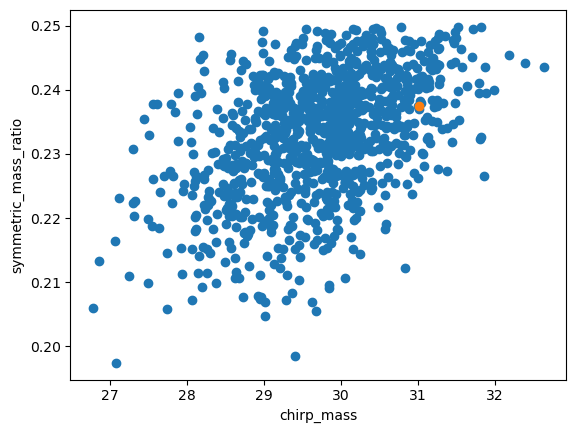

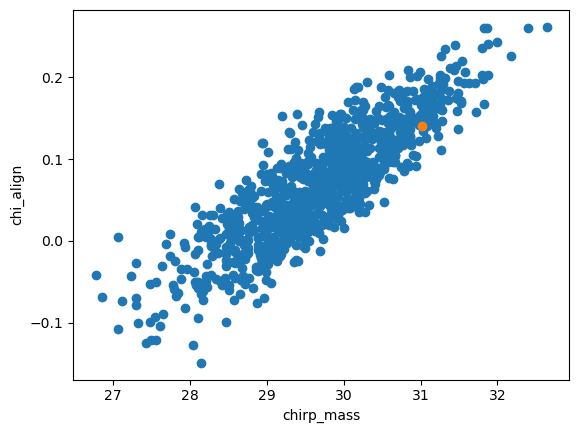

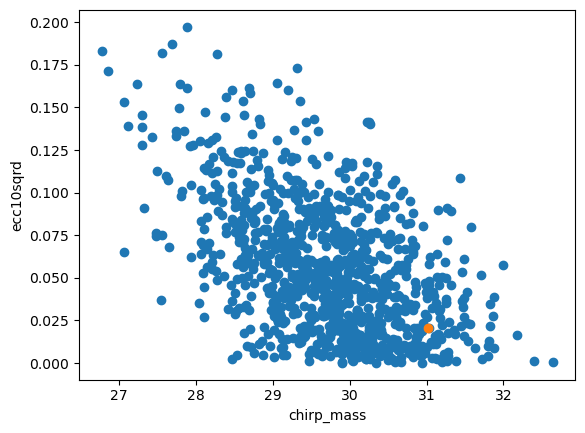

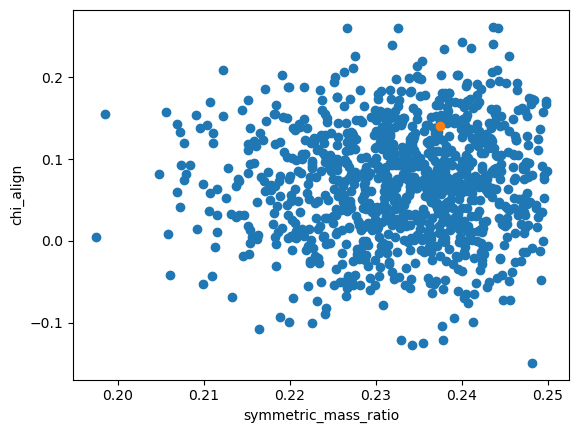

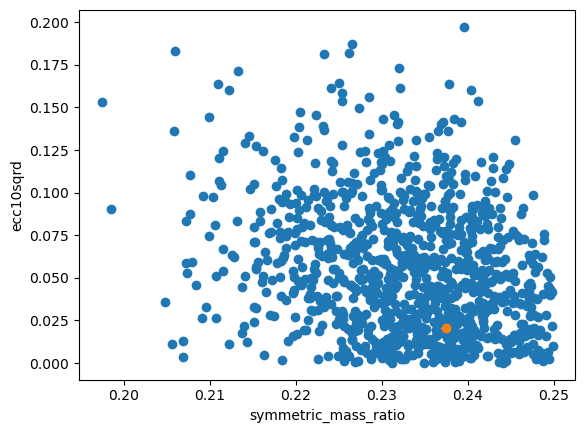

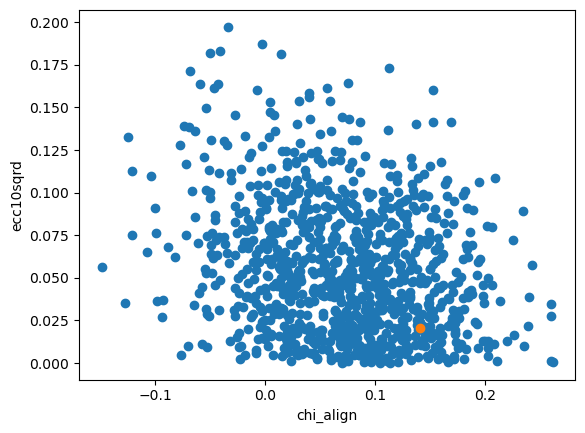

(array([0.01760005, 0.05736313, 0.06844465, 0.06257796,
        0.06257796, 0.06192611, 0.04171864, 0.04302235,
        0.03780752, 0.03585196, 0.02346674, 0.02216303,
        0.01955561, 0.02151117, 0.0169482 , 0.01760005,
        0.0084741 , 0.00717039, 0.00521483, 0.00717039,
        0.00325927, 0.00260742, 0.00195556, 0.00195556,
        0.        , 0.00195556, 0.        , 0.        ,
        0.00130371, 0.00065185]),
 array([ 0.18881649,  1.72290288,  3.25698927,  4.79107566,
         6.32516205,  7.85924844,  9.39333483, 10.92742121,
        12.4615076 , 13.99559399, 15.52968038, 17.06376677,
        18.59785316, 20.13193955, 21.66602594, 23.20011233,
        24.73419872, 26.26828511, 27.8023715 , 29.33645789,
        30.87054428, 32.40463067, 33.93871705, 35.47280344,
        37.00688983, 38.54097622, 40.07506261, 41.609149  ,
        43.14323539, 44.67732178, 46.21140817]),
 [<matplotlib.patches.Polygon at 0x7f6f21648ee0>])

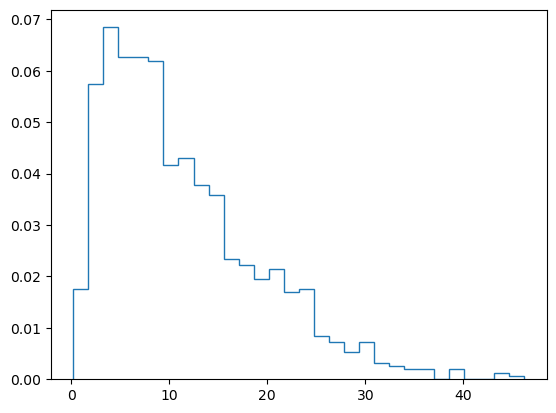

In [37]:
inj_x = [all_inj_params['posterior_samples']['chirp_mass'][0], all_inj_params['posterior_samples']['symmetric_mass_ratio'][0], all_inj_params['posterior_samples']['chi_align'][0], all_inj_params['posterior_samples']['ecc10'][0]**2]
samples = metric.generate_samples(npts=10**3)
keys = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
for i in range(len(keys)-1):
    for j in range(i+1, len(keys)):
        plt.scatter(samples[keys[i]], samples[keys[j]])
        plt.scatter(inj_x[i], inj_x[j])
        plt.xlabel(keys[i])
        plt.ylabel(keys[j])
        plt.show()

dx_dists = []
for i in range(len(samples[keys[0]])):
    sample = [samples[key][i] for key in keys]
    for j, k in enumerate(dx_directions):
        sample[j] -= metric.x[k][0]
    x_dx_coords = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), sample)
    dx_dists.append(np.sqrt(np.sum(x_dx_coords**2)))
plt.hist(dx_dists, bins=30, histtype='step', density=True)

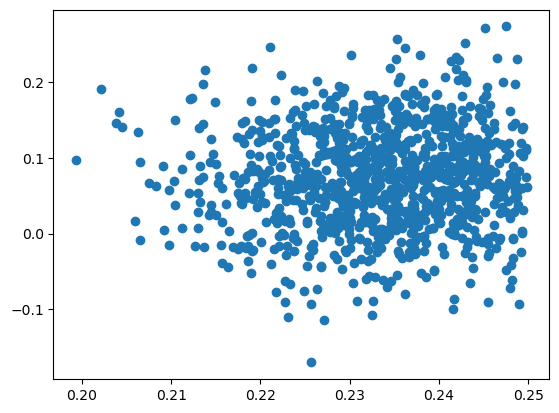

In [30]:
plt.scatter(samples['symmetric_mass_ratio'], samples['chi_align'])